In [177]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from typing import Dict, List

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("All imports successful.")

All imports successful.


In [178]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
df = pd.read_csv("/content/drive/MyDrive/Capstone/triad_130_transcripts.csv")
added = pd.read_csv("/content/drive/MyDrive/Capstone/new_urgent_transcripts.csv")
new_set = pd.read_csv("/content/drive/MyDrive/Capstone/triad_100_new_transcripts.csv")
df = pd.concat([df, added])
df = pd.concat([df, new_set])

Mounted at /content/drive


In [179]:
print(f"Loaded {len(df)} transcripts")
print("\nLabel distribution:")
print(df["label"].value_counts())

Loaded 250 transcripts

Label distribution:
label
Urgent         89
Semi-Urgent    88
Routine        73
Name: count, dtype: int64


In [180]:

def normalize_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def extract_patient_text(transcript: str) -> str:
    """Extract only [Patient] turns and normalize."""
    turns = re.findall(r"\[Patient\]:\s*(.+?)(?=\[AI Bot\]:|\Z)", transcript, re.DOTALL)
    combined = " ".join(t.strip() for t in turns)
    return normalize_text(combined)


def compile_patterns(patterns: List[str]) -> List[re.Pattern]:
    return [re.compile(p) for p in patterns]


def match_any(patterns: List[re.Pattern], text: str) -> bool:
    return any(p.search(text) for p in patterns)


def is_negated(text: str, keyword: str) -> bool:
    """Simple negation detection within a small window before keyword."""
    pattern = re.compile(rf"(no|not|without)\s+(?:\w+\s+){{0,2}}{keyword}")
    return bool(pattern.search(text))

In [181]:
BREATHING_PATTERNS = compile_patterns([
    r"trouble breathing",
    r"difficulty breathing",
    r"(can.?t|cannot|unable to) breathe",
    r"harder to breathe",
    r"breathing is.{0,20}hard",
    r"noisy.{0,15}breath",
    r"squeaky sound",
    r"shortness of breath",
    r"breath.{0,20}pooling",
    r"breathe.{0,10}mouth",
    r"breathing.{0,15}blocked",
])

def feat_breathing_difficulty(text: str) -> int:
    return int(match_any(BREATHING_PATTERNS, text) and not is_negated(text, "breathing"))


THROAT_SWELLING_PATTERNS = compile_patterns([
    r"throat.{0,20}swelling",
    r"throat is swelling",
    r"swelling up",
    r"neck.{0,15}swelling",
    r"massive swelling",
    r"neck.{0,10}puffy",
    r"throat.{0,15}closing",
    r"tight.{0,10}throat",
    r"swelling under.{0,20}chin",
])

def feat_throat_swelling(text: str) -> int:
    return int(match_any(THROAT_SWELLING_PATTERNS, text))


BLOOD_PATTERN = re.compile(r"\bblood\b|\bbleed\b|\bbleeding\b")

ACTIVE_BLEEDING_PATTERNS = compile_patterns([
    r"right now",
    r"still going",
    r"won'?t stop",
    r"will not stop",
    r"can'?t get it to stop",
    r"still bleeding",
    r"(twenty|thirty|forty|45|30|20)\s*minute",
    r"keeps? coming",
    r"non.?stop",
    r"currently bleeding",
])

def feat_active_bleeding(text: str) -> int:
    blood  = bool(BLOOD_PATTERN.search(text))
    active = match_any(ACTIVE_BLEEDING_PATTERNS, text)
    return int(blood and active)

RESOLVED_BLEED_PATTERNS = compile_patterns([
    r"(stopped|stop).{0,30}(ago|now|already|earlier|this morning)",
    r"no longer bleeding",
    r"bleed.{0,20}stopped",
    r"it.{0,10}stopped",
    r"stopped on its own",
])

def feat_resolved_bleeding(text: str) -> int:
    blood = bool(BLOOD_PATTERN.search(text))
    resolved = match_any(RESOLVED_BLEED_PATTERNS, text)
    return int(blood and resolved)

SUDDEN_HEARING_PATTERNS = compile_patterns([
    r"completely lost hearing",
    r"(can.?t|cannot|unable to) hear anything",
    r"total.{0,15}hearing",
    r"hearing.{0,15}gone",
    r"hearing.{0,15}muffled suddenly",
    r"lost.{0,20}hearing.{0,20}(morning|today|suddenly|overnight)",
    r"woke up.{0,40}(can'?t|cannot|couldn'?t).{0,15}hear",
    r"turned off a switch",
    r"both ears.{0,30}(sudden|woke|overnight|this morning)",
])

def feat_sudden_hearing_loss(text: str) -> int:
    return int(match_any(SUDDEN_HEARING_PATTERNS, text))


VERTIGO_PATTERNS = compile_patterns([
    r"room.{0,10}spinning",
    r"spinning.{0,10}room",
    r"spinning badly",
    r"can.{0,5}barely walk",
    r"can.{0,5}barely stand",
    r"can.{0,5}walk.{0,10}straight",
    r"severely.{0,15}dizz",
    r"off balance.{0,15}severe",
])

def feat_severe_vertigo(text: str) -> int:
    spinning     = match_any(VERTIGO_PATTERNS, text)
    vomit_combo  = (
        bool(re.search(r"vomit|vomited|threw up", text)) and
        bool(re.search(r"dizz|vertig|spinning|balance", text))
    )
    return int(spinning or vomit_combo)


AIRWAY_OBSTRUCTION_PATTERNS = compile_patterns([
    r"stuck.{0,20}throat",
    r"something.{0,15}(in my |in the )?throat",
    r"lodged.{0,15}throat",
    r"can feel.{0,20}(in my throat|stuck)",
    r"went in wrong",
    r"swallowed.{0,30}(stuck|throat|feel)",
    r"feels? stuck",
    r"bead.{0,20}(nose|nostril)",
    r"put.{0,15}(up|in).{0,10}(nose|nostril)",
])

def feat_airway_obstruction(text: str) -> int:
    return int(match_any(AIRWAY_OBSTRUCTION_PATTERNS, text))



In [182]:

SWALLOW_PATTERNS = compile_patterns([
    r"hard to swallow",
    r"hurts to swallow",
    r"pain.{0,15}swallow",
    r"swallowing.{0,15}(hard|painful|difficult)",
    r"trouble swallowing",
    r"difficulty swallowing",
    r"drooling",
    r"can.{0,5}barely swallow",
    r"saliva.{0,15}(hard|hurt|painful)",
    r"(can't|cannot|unable to|hard to).{0,5}swallow"
])

def feat_swallowing_difficulty(text: str) -> int:
    return int(match_any(SWALLOW_PATTERNS, text))


TEMP_PATTERN = re.compile(r"\b(9[5-9]|10[0-9]|1[01][0-9])(?:\.\d)?\b")

def _extract_max_temp(text: str) -> float:
    temps = TEMP_PATTERN.findall(text)
    return max((float(t) for t in temps), default=0.0)

def feat_high_fever(text: str) -> int:
    return int(_extract_max_temp(text) >= 103.0)

def feat_moderate_fever(text: str) -> int:
    temp = _extract_max_temp(text)
    return int(101.0 <= temp < 103.0)


NECK_LUMP_PATTERNS = compile_patterns([
    r"lump.{0,20}neck",
    r"bump.{0,20}neck",
    r"neck.{0,20}lump",
    r"mass.{0,20}neck",
    r"lump.{0,15}side.{0,15}neck",
    r"lump.{0,15}jaw",
    r"bump.{0,15}throat",
])

def feat_neck_lump(text: str) -> int:
    return int(match_any(NECK_LUMP_PATTERNS, text))


HOARSENESS_PATTERNS = compile_patterns([
    r"hoarse",
    r"losing.{0,10}voice",
    r"voice.{0,15}disappear",
    r"voice.{0,15}different",
    r"voice.{0,15}gone",
    r"can.{0,5}barely.{0,10}whisper",
    r"can.{0,5}barely speak",
])

def feat_prolonged_hoarseness(text: str) -> int:
    """Hoarseness + duration > a few days — red flag for laryngeal pathology."""
    voice_change = match_any(HOARSENESS_PATTERNS, text)
    prolonged    = bool(re.search(r"\b(week|weeks|month|months|\d+ day|\d+ week)\b", text))
    return int(voice_change and prolonged)


RECENT_SURGERY_PATTERNS = compile_patterns([
    r"(just |last |this ).{0,10}(had|had a).{0,15}surgery",
    r"surgery.{0,20}(last week|few days|ago|recently)",
    r"tonsils? out",
    r"sinus surgery",
    r"had.{0,15}(procedure|operation).{0,20}(last|few|this)",
    r"post.?op",
    r"recovering from.{0,15}surgery",
])

def feat_recent_surgery(text: str) -> int:
    """Recent surgical procedure — raises suspicion for post-op complication."""
    return int(match_any(RECENT_SURGERY_PATTERNS, text))


WEIGHT_LOSS_PATTERNS = compile_patterns([
    r"lost.{0,10}\d+.{0,10}pound",
    r"losing weight.{0,20}(without|not trying|can't explain)",
    r"weight loss.{0,20}(without|unintentional|unexplained)",
    r"weight.{0,10}dropped",
    r"\d+.{0,10}pound.{0,20}without trying",
])

def feat_unexplained_weight_loss(text: str) -> int:
    """Unintentional weight loss — systemic red flag."""
    return int(match_any(WEIGHT_LOSS_PATTERNS, text))


EAR_FB_PATTERNS = compile_patterns([
    r"something.{0,20}(in my ear|in the ear|in.{0,5}ear canal)",
    r"(object|bug|bead|button).{0,20}ear",
    r"ear.{0,20}(something|object|stuck|foreign)",
    r"felt.{0,20}(go|went).{0,10}(in|into).{0,10}ear",
    r"went.{0,10}in.{0,10}(my ear|the ear)",
])

def feat_ear_foreign_body(text: str) -> int:
    """Foreign body in the ear canal — needs removal, not typically an emergency."""
    return int(match_any(EAR_FB_PATTERNS, text))


DIZZINESS_PATTERNS = compile_patterns([
    r"\bdizz",
    r"\bvertig",
    r"off balance",
    r"loss of balance",
    r"unsteady",
    r"lightheaded",
    r"spinning",
    r"(dizz|vertig|spinning|lightheaded|off balance)",
])

def feat_dizziness(text: str) -> int:
    """Any dizziness/balance disturbance including mild or episodic.
    Severe cases are captured by feat_severe_vertigo; this catches the rest."""
    return int(match_any(DIZZINESS_PATTERNS, text))



In [183]:
SUDDEN_ONSET_PATTERNS = compile_patterns([
    r"woke up.{0,30}(and|with|to)",
    r"this morning",
    r"tonight",
    r"within the last.{0,20}(hour|day)",
    r"just happened",
    r"all at once",
    r"out of nowhere",
    r"went to bed.{0,20}fine",
    r"started today",
    r"happened.{0,10}today",
    r"came on.{0,15}(fast|quickly|suddenly|rapid)",
    r"overnight",
    r"very suddenly",
])

def feat_sudden_onset(text: str) -> int:
    return int(match_any(SUDDEN_ONSET_PATTERNS, text))


WORSENING_PATTERNS = compile_patterns([
    r"getting worse",
    r"getting harder",
    r"spreading",
    r"more and more",
    r"dramatically worse",
    r"much worse.{0,15}(today|now|this)",
    r"progressively worse",
    r"rapidly.{0,10}(worsen|deteriorat|progress)",
    r"getting.{0,10}(bigger|worse|harder|more)",
    r"(getting|becoming|feels).{0,10}(worse|harder|more painful)",

])

def feat_rapidly_worsening(text: str) -> int:
    return int(match_any(WORSENING_PATTERNS, text))


STABLE_PATTERNS = compile_patterns([
    r"\bstable\b",
    r"same as always",
    r"same old",
    r"no real change",
    r"hasn.t changed",
    r"same.{0,10}last visit",
    r"no change",
    r"hasn.t gotten worse",
    r"about the same",
    r"not getting worse",
])

def feat_stable(text: str) -> int:
    return int(match_any(STABLE_PATTERNS, text))


CHRONIC_PATTERN = re.compile(
    r"\b(months|years|long.?standing|chronic|for years|for a long time"
    r"|always had|my whole life|lifelong|ongoing)\b"
)

def feat_chronic_duration(text: str) -> int:
    return int(bool(CHRONIC_PATTERN.search(text)))


ACUTE_DURATION_PATTERNS = compile_patterns([
    r"\btoday\b",
    r"this morning",
    r"tonight",
    r"within.{0,10}hour",
    r"\bhours? ago\b",
    r"just now",
    r"(one|two|three|a few|several|a couple).{0,10}day",
    r"\d.{0,5}day.{0,5}ago",
    r"since (yesterday|last night|this morning)",
    r"started (yesterday|last night|this morning|today)",
])

def feat_acute_duration(text: str) -> int:
    """Onset within hours to a couple of days — amplifies urgency of clinical features."""
    return int(match_any(ACUTE_DURATION_PATTERNS, text))


In [184]:
ROUTINE_PATTERNS = compile_patterns([
    r"\bannual\b",
    r"follow.?up",
    r"check.?up",
    r"due for my",
    r"tune.?up",
    r"\bconsultation\b",
    r"routine",
    r"scheduled.{0,15}(visit|appointment|check)",
    r"regular check",
    r"coming in for.{0,15}(check|visit|follow)",
])

def feat_routine_signal(text: str) -> int:
    return int(match_any(ROUTINE_PATTERNS, text))


ALLERGY_PATTERNS = compile_patterns([
    r"\ballerg",
    r"runny nose",
    r"\bsneez",
    r"itchy eyes",
    r"seasonal",
    r"antihistamine",
    r"loratadine",
    r"zyrtec",
    r"claritin",
    r"hay fever",
    r"post.?nasal drip",
])

def feat_allergies(text: str) -> int:
    return int(match_any(ALLERGY_PATTERNS, text))


REFERRAL_PATTERNS = compile_patterns([
    r"my doctor sent",
    r"referred me",
    r"my primary.{0,10}(said|told|sent|recommended)",
    r"doctor.{0,10}referred",
    r"primary care.{0,10}(said|sent|recommended|suggested)",
    r"doctor.{0,10}said to see",
    r"sent me (here|to you|to this)",
])

def feat_referral(text: str) -> int:
    """Referred by primary care — indicates a planned, non-emergency pathway."""
    return int(match_any(REFERRAL_PATTERNS, text))


GRADUAL_HEARING_PATTERNS = compile_patterns([
    r"gradual.{0,20}hear",
    r"slowly.{0,15}(losing|lost).{0,10}hear",
    r"hearing.{0,20}(over the years|over.*year|gradual|slowly)",
    r"hearing.{0,20}(worse|declining).{0,20}(year|month|gradual)",
    r"(year|years).{0,20}hearing.{0,20}(worse|less|declining)",
])

def feat_gradual_hearing_loss(text: str) -> int:
    """Slow, progressive hearing loss over months/years — Routine signal."""
    return int(match_any(GRADUAL_HEARING_PATTERNS, text))



In [185]:
def extract_features(transcript: str) -> Dict[str, int]:
    text = extract_patient_text(transcript)

    features = {
        # --- Urgent ---
        "breathing_difficulty":    feat_breathing_difficulty(text),
        "throat_swelling":         feat_throat_swelling(text),
        "active_bleeding":         feat_active_bleeding(text),
        "sudden_hearing_loss":     feat_sudden_hearing_loss(text),
        "severe_vertigo":          feat_severe_vertigo(text),
        "airway_obstruction":      feat_airway_obstruction(text),
        # --- Moderate (Semi-Urgent) ---
        "swallowing_difficulty":   feat_swallowing_difficulty(text),
        "high_fever":              feat_high_fever(text),
        "moderate_fever":          feat_moderate_fever(text),
        "neck_lump":               feat_neck_lump(text),
        "prolonged_hoarseness":    feat_prolonged_hoarseness(text),
        "recent_surgery":          feat_recent_surgery(text),
        "unexplained_weight_loss": feat_unexplained_weight_loss(text),
        "ear_foreign_body":        feat_ear_foreign_body(text),
        "dizziness":               feat_dizziness(text),
        # --- Context ---
        "sudden_onset":            feat_sudden_onset(text),
        "rapidly_worsening":       feat_rapidly_worsening(text),
        "chronic_duration":        feat_chronic_duration(text),
        "stable":                  feat_stable(text),
        "acute_duration":          feat_acute_duration(text),
        # --- Routine ---
        "routine_signal":          feat_routine_signal(text),
        "allergies":               feat_allergies(text),
        "referral":                feat_referral(text),
        "gradual_hearing_loss":    feat_gradual_hearing_loss(text),
    }

    features["airway_risk"] = int(
        features["breathing_difficulty"] or
        features["throat_swelling"] or
        features["airway_obstruction"]
    )

    features["infection_risk"] = int(
        features["high_fever"] or
        (features["moderate_fever"] and features["rapidly_worsening"])
    )

    features["subacute_duration"] = int(
      not features["acute_duration"] and
      not features["chronic_duration"]
    )

    features["semi_urgent_signal"] = int(
      (features["swallowing_difficulty"] and not features["airway_risk"]) or
      (features["moderate_fever"] and not features["high_fever"]) or
      (features["neck_lump"] and features["unexplained_weight_loss"]) or
      features["ear_foreign_body"] or
      features["prolonged_hoarseness"]
    )

    features["active_bleeding"] = int(
      feat_active_bleeding(text) and not feat_resolved_bleeding(text)
    )

    return features

print("Feature functions defined. Total features:", len(extract_features("test")))



Feature functions defined. Total features: 28


In [186]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

In [187]:
df_features = df["transcript"].apply(extract_features).apply(pd.Series)
X = df_features
y = df["label"].str.lower().str.strip()

print(f"Feature matrix shape: {X.shape}")
print("\nFeature firing rates per class:")
X_labeled = X.copy()
X_labeled["label"] = y.values
print(X_labeled.groupby("label").mean().round(2).T.to_string())

Feature matrix shape: (250, 28)

Feature firing rates per class:
label                    routine  semi-urgent  urgent
breathing_difficulty        0.05         0.01    0.07
throat_swelling             0.00         0.00    0.06
active_bleeding             0.00         0.00    0.07
sudden_hearing_loss         0.00         0.00    0.07
severe_vertigo              0.00         0.03    0.07
airway_obstruction          0.01         0.01    0.06
swallowing_difficulty       0.00         0.06    0.17
high_fever                  0.00         0.03    0.12
moderate_fever              0.01         0.09    0.11
neck_lump                   0.03         0.03    0.07
prolonged_hoarseness        0.01         0.09    0.09
recent_surgery              0.03         0.03    0.04
unexplained_weight_loss     0.00         0.00    0.02
ear_foreign_body            0.01         0.01    0.01
dizziness                   0.04         0.12    0.19
sudden_onset                0.00         0.11    0.43
rapidly_worsening

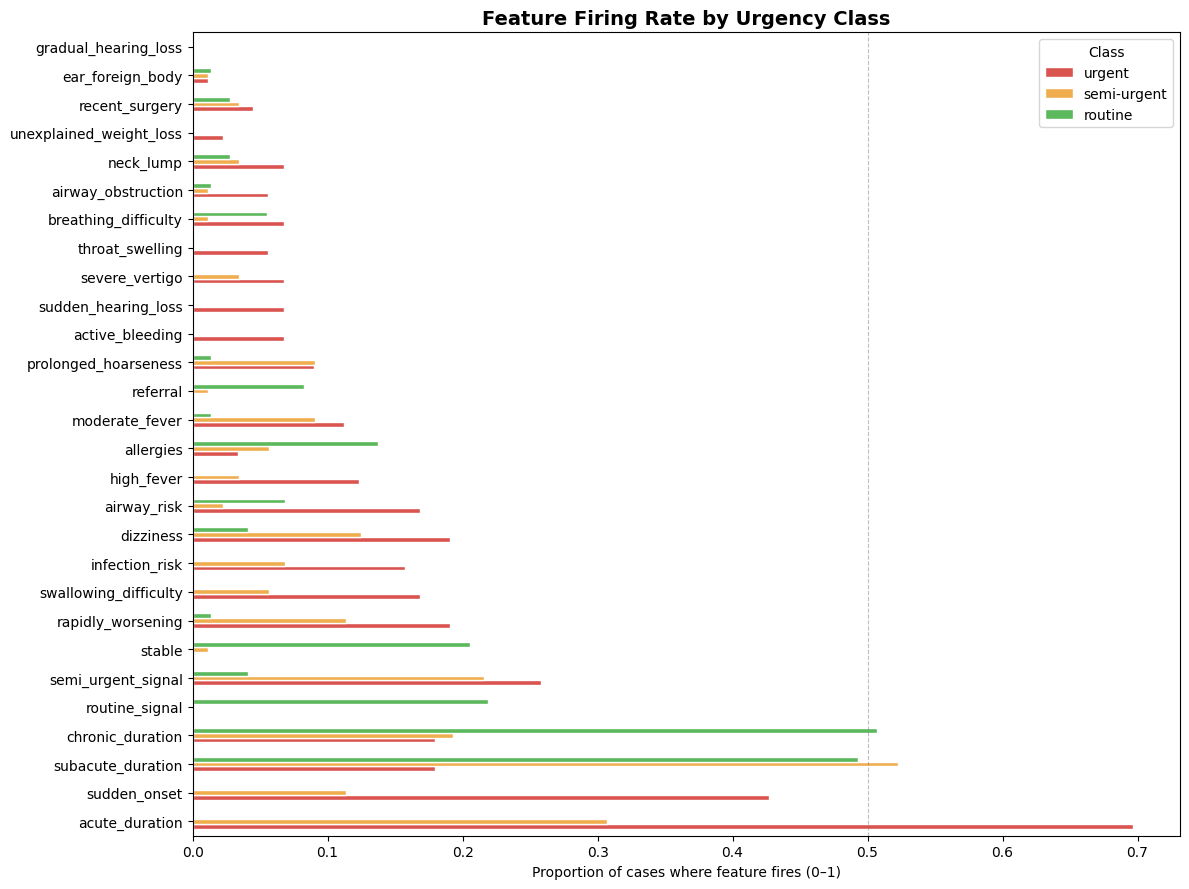

In [188]:
label_means = X_labeled.groupby("label").mean().T
label_means["max_spread"] = label_means.max(axis=1) - label_means.min(axis=1)
label_means_sorted = label_means.sort_values("max_spread", ascending=False)

fig, ax = plt.subplots(figsize=(12, 9))
label_means_sorted[["urgent", "semi-urgent", "routine"]].plot(
    kind="barh", ax=ax,
    color=["#d9534f", "#f0ad4e", "#5cb85c"],
    edgecolor="white"
)
ax.set_title("Feature Firing Rate by Urgency Class", fontsize=14, fontweight="bold")
ax.set_xlabel("Proportion of cases where feature fires (0–1)")
ax.axvline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax.legend(title="Class")
plt.tight_layout()
plt.savefig("feature_firing_rates.png", dpi=150, bbox_inches="tight")
plt.show()

In [189]:
from sklearn.ensemble import RandomForestClassifier

# 1. Define custom weights to penalize missing 'urgent' cases heavily
custom_weights = {
    'routine': 1,
    'semi-urgent': 1,
    'urgent': 1.5  # This forces the model to prioritize urgent recall
}

# 2. Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=2,
    class_weight=custom_weights,
    random_state=42
)

# 3. Fit and get probabilities for thresholding
rf_model.fit(X, y)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Example of running cross-validation with the safety threshold
y_pred_rf = cross_val_predict(rf_model, X, y, cv=cv)
print(classification_report(y, y_pred_rf))

              precision    recall  f1-score   support

     routine       0.76      0.73      0.74        73
 semi-urgent       0.57      0.48      0.52        88
      urgent       0.67      0.80      0.73        89

    accuracy                           0.66       250
   macro avg       0.66      0.67      0.66       250
weighted avg       0.66      0.66      0.66       250



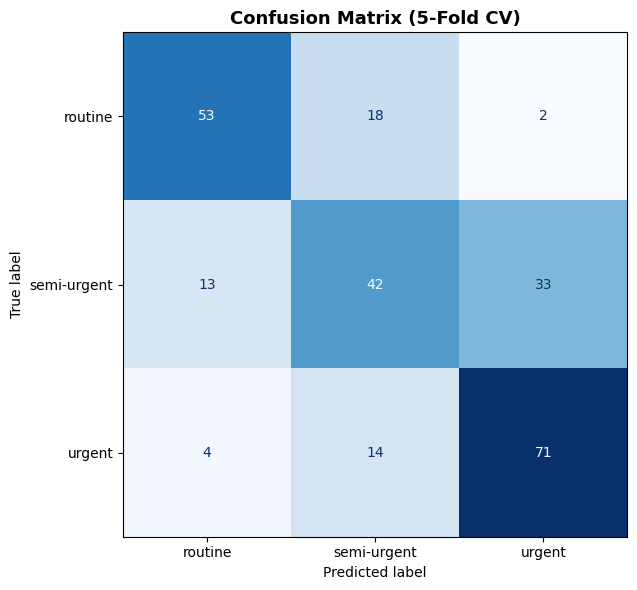

In [190]:
class_order = ["routine", "semi-urgent", "urgent"]
cm = confusion_matrix(y, y_pred_rf, labels=class_order)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format="d"
)
ax.set_title("Confusion Matrix (5-Fold CV)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

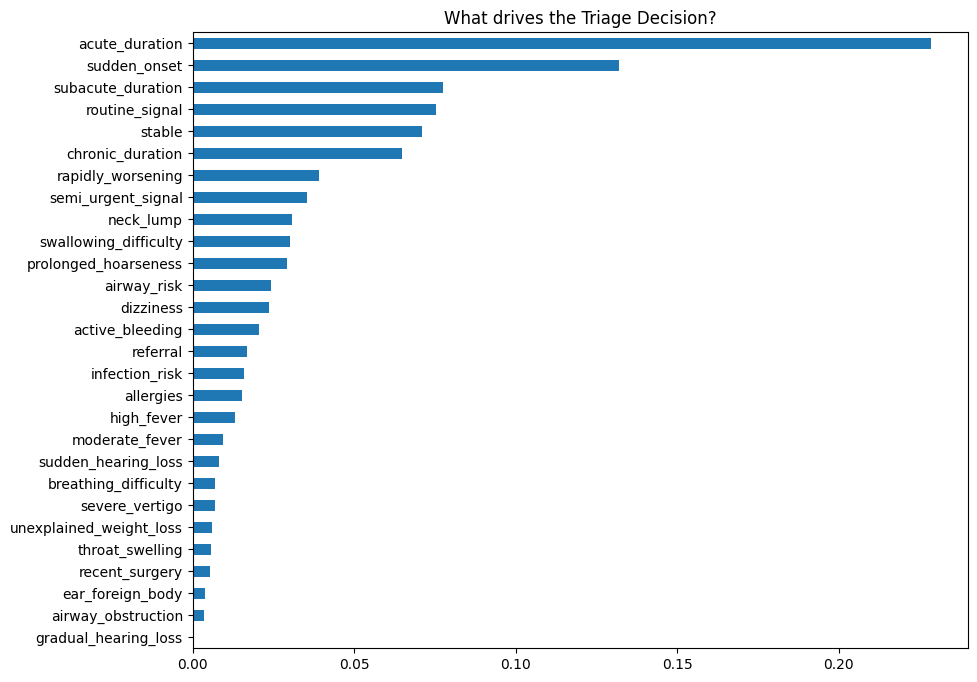

In [191]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 8))
plt.title("What drives the Triage Decision?")
plt.show()

In [192]:
texts = df["transcript"].apply(extract_patient_text)
errors = pd.DataFrame({
    "true": y,
    "pred": y_pred_rf,
    "text": texts,
})

false_negatives = errors[
    (errors["true"] == "urgent") &
    (errors["pred"] != "urgent")
]

for _, row in false_negatives.iterrows():
    print("TEXT:\n", row["text"])
    print("TRUE:", row["true"])
    print("PRED:", row["pred"])
    print("Confidence:", rf_model.predict_proba(X.loc[[row.name]])[0, 1])
    print("-" * 80)



TEXT:
 returning. i just had surgery here last week. thomas reyes. may 22nd, 1978. 789 sparks boulevard, sparks, nevada. i had my tonsils out five days ago and my throat won't stop bleeding. there's blood in my mouth right now. yes, it's been going for about twenty minutes and it will not stop. heavy. i keep spitting it out. i'm really scared. a little bit. it feels like it's pooling in my throat.
TRUE: urgent
PRED: semi-urgent
Confidence: 0.33387115529336375
--------------------------------------------------------------------------------
TEXT:
 returning patient. linda marchetti. september 29th, 1966. 14 sage street, reno, nevada. my nose has been bleeding for over 45 minutes and i cannot get it to stop. i've been pinching it this whole time. yes it's still going. just the left side but there's a lot. yes i take warfarin. i have a heart condition. a little yes. i think so. i feel nauseous.
TRUE: urgent
PRED: semi-urgent
Confidence: 0.3716842349332502
----------------------------------

In [193]:
texts = df["transcript"].apply(extract_patient_text)
errors = pd.DataFrame({
    "true": y,
    "pred": y_pred_rf,
    "text": texts,
})

false_negatives = errors[
    (errors["true"] == "semi-urgent") &
    (errors["pred"] != "semi-urgent")
]

for _, row in false_negatives.iterrows():
    print("TEXT:\n", row["text"])
    print("TRUE:", row["true"])
    print("PRED:", row["pred"])
    print("Confidence:", rf_model.predict_proba(X.loc[[row.name]])[0, 1])
    print("-" * 80)



TEXT:
 returning patient. angela robinson. october 8th, 1980. 200 court street, reno, nevada. i've been on antibiotics for a week for an ear infection and it is not getting better. if anything it's worse. amoxicillin. yes 101.5 for the past two days. a little yellow drainage started yesterday. yes it's very muffled. no.
TRUE: semi-urgent
PRED: urgent
Confidence: 0.45479221859353686
--------------------------------------------------------------------------------
TEXT:
 new patient. craig ferguson. july 7th, 1972. 515 wheeler court, sparks, nevada. i woke up this morning and the room was spinning badly. it settled a bit but i still feel off balance. it comes and goes. mostly when i turn my head. slight ringing in my right ear. yes i vomited twice this morning. no none of that. never like this.
TRUE: semi-urgent
PRED: urgent
Confidence: 0.18291621751267126
--------------------------------------------------------------------------------
TEXT:
 new patient. donald huang. january 17th, 1960.

In [194]:
def rule_based_override(features: dict) -> str | None:
    """
    Returns urgency label if a hard safety rule fires, otherwise None.
    These rules bypass the RF and always produce 'urgent' at confidence=1.0.
    """
    # Airway emergency (highest priority)
    if features["airway_risk"]:
      return "urgent"

    # Active uncontrolled bleeding
    if features["active_bleeding"]:
        return "urgent"

    # Sudden sensorineural hearing loss
    if features["sudden_hearing_loss"]:
        return "urgent"

    # Severe incapacitating vertigo
    if features["severe_vertigo"]:
        return "urgent"

    return None

In [195]:
def predict_rf(model, features: dict) -> tuple[str, float]:
    """Returns (predicted_label, confidence)."""
    X_single = pd.DataFrame([features])
    probs    = model.predict_proba(X_single)[0]
    pred     = model.classes_[probs.argmax()]
    confidence = probs.max()
    return pred, float(confidence)

In [196]:
def hybrid_triage(model, transcript: str) -> dict:
    """
    Main triage pipeline: rule-based override → RF.

    Returns a dict with:
      urgency     : 'urgent' | 'semi-urgent' | 'routine'
      source      : 'rule' | 'decision_tree'
      confidence  : float (1.0 for rule overrides)
      reason      : str (only present for rule overrides)
      features    : dict of all feature values
    """
    # Step 1: Extract features
    features = extract_features(transcript)

    # Step 2: Rule-based override
    rule_result = rule_based_override(features)
    if rule_result:
        return {
            "urgency":    rule_result,
            "source":     "rule",
            "confidence": 1.0,
            "reason":     "Critical safety rule triggered",
            "features":   features,
        }

    rf_pred, rf_conf = predict_rf(model, features)
    return {
        "urgency":    rf_pred,
        "source":     "random_forest",
        "confidence": rf_conf,
        "features":   features,
    }



In [197]:
test_scripts = [
    "[Patient]: My nose has been bleeding for about 30 minutes and it won't stop. I've tried pinching it but it's still going.",
    "[Patient]: I went to bed fine last night but this morning I completely lost hearing in my left ear. I can't hear anything at all.",
    "[Patient]: The room is spinning really badly and I can barely stand. I also threw up twice because of how dizzy I feel.",
    "[Patient]: I have a fever of 103 and my throat pain is getting much worse today. It's becoming really hard to swallow.",
    "[Patient]: It hurts to swallow and my throat has been sore for a few days. It's uncomfortable but I can still eat.",
    "[Patient]: I noticed a lump on the side of my neck about two weeks ago and it hasn't gone away.",
    "[Patient]: My voice has been hoarse for about three weeks now and it doesn't seem to be improving.",
    "[Patient]: I have a fever around 101 and a sore throat that started yesterday.",
    "[Patient]: I've had a runny nose and sneezing for the past few weeks, especially during the day. I think it's just allergies.",
    "[Patient]: Over the past couple of years my hearing has slowly been getting worse, especially in crowded places.",
    "[Patient]: I'm coming in for a follow-up appointment after my sinus surgery last month. Everything feels about the same.",
    "[Patient]: I've had sinus pressure for years and it's pretty much the same as always. No real changes recently.",
    "[Patient]: It feels like something is stuck in my throat and I can't swallow properly. It's getting worse quickly.",
    "[Patient]: I'm a bit dizzy and not feeling great, and I did throw up once earlier.",
]

print("Test case results:\n")
for transcript in test_scripts:
    result = hybrid_triage(rf_model, transcript)
    src    = result["source"].upper()
    conf   = f"{result['confidence']:.0%}"
    fired  = [k for k, v in result["features"].items() if v == 1]
    print(f"[{result['urgency'].upper():11s}] ({src}, {conf}) | fired: {fired}")
    print(f"  > {transcript[11:90]}...")
    print()

Test case results:

[URGENT     ] (RULE, 100%) | fired: ['active_bleeding', 'subacute_duration']
  > My nose has been bleeding for about 30 minutes and it won't stop. I've tried pi...

[URGENT     ] (RULE, 100%) | fired: ['sudden_hearing_loss', 'sudden_onset', 'acute_duration']
  > I went to bed fine last night but this morning I completely lost hearing in my ...

[URGENT     ] (RULE, 100%) | fired: ['severe_vertigo', 'dizziness', 'subacute_duration']
  > The room is spinning really badly and I can barely stand. I also threw up twice...

[URGENT     ] (RANDOM_FOREST, 81%) | fired: ['swallowing_difficulty', 'high_fever', 'rapidly_worsening', 'acute_duration', 'infection_risk', 'semi_urgent_signal']
  > I have a fever of 103 and my throat pain is getting much worse today. It's beco...

[URGENT     ] (RANDOM_FOREST, 73%) | fired: ['swallowing_difficulty', 'acute_duration', 'semi_urgent_signal']
  > It hurts to swallow and my throat has been sore for a few days. It's uncomforta...

[SEMI-U

In [198]:
import pickle

with open("/content/drive/MyDrive/Capstone/urgency_rf_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

print("Model saved.")

Model saved.
